In [1]:
import pandas as pd

In [2]:
radiomics = pd.read_csv("cross_eval/abdomen_atlas_pro/all_radiomics_train.csv")

datapairs = pd.read_csv("cross_eval/abdomen_atlas_pro/Datapairs_with_masks.csv")


In [4]:
datapairs["normalized_time_delta"].max()

np.float64(4.6868426378303605)

In [3]:
"""
correlation_check.py

Checks whether tumor shape change (ct1 vs ct0) actually correlates with
elapsed time (delta_t) in the real data — independent of the model. If it
doesn't, that's strong evidence cond_mlp's near-zero delta_t sensitivity is
a correct response to a weak/absent signal in the data, not a training bug.

Assumes:
  radiomics: one row per bdmap_id, with radiomics shape columns
             (e.g. original_shape_MeshVolume, diameter_x_mm, etc.)
  datapairs: one row per (ct0_bdmap, ct1_bdmap) pair, with unix_delta and
             normalized_time_delta columns.
"""

import pandas as pd
import numpy as np
from scipy import stats


# Radiomics columns to check correlation for. Adjust to match whatever
# columns actually exist in your `radiomics` dataframe.
SHAPE_COLUMNS = [
    "original_shape_MeshVolume",
    "original_shape_MajorAxisLength",
    "original_shape_MinorAxisLength",
    "original_shape_LeastAxisLength",
    "original_shape_Maximum3DDiameter",
    "original_shape_SurfaceArea",
    "original_shape_Sphericity",
    "original_shape_Elongation",
    "original_shape_Flatness",
]

TIME_COLUMNS = ["unix_delta", "normalized_time_delta"]


def build_shape_change_df(radiomics: pd.DataFrame, datapairs: pd.DataFrame,
                           bdmap_col: str = "bdmap_id",
                           shape_columns: list = SHAPE_COLUMNS) -> pd.DataFrame:
    """
    Merges radiomics features onto datapairs for both ct0 and ct1, then
    computes per-feature deltas (ct1 - ct0) and percent change.
    """
    radiomics = radiomics.copy()
    radiomics = radiomics.drop_duplicates(subset=[bdmap_col])

    # Merge ct0 features
    df = datapairs.merge(
        radiomics[[bdmap_col] + shape_columns],
        left_on="ct0_bdmap", right_on=bdmap_col, how="inner",
        suffixes=("", "_ct0"),
    )
    df = df.rename(columns={c: f"{c}_ct0" for c in shape_columns})
    df = df.drop(columns=[bdmap_col])

    # Merge ct1 features
    df = df.merge(
        radiomics[[bdmap_col] + shape_columns],
        left_on="ct1_bdmap", right_on=bdmap_col, how="inner",
        suffixes=("", "_ct1"),
    )
    df = df.rename(columns={c: f"{c}_ct1" for c in shape_columns})
    df = df.drop(columns=[bdmap_col])

    dropped = len(datapairs) - len(df)
    if dropped > 0:
        print(f"Warning: dropped {dropped}/{len(datapairs)} pairs "
              f"due to missing radiomics for ct0 or ct1 bdmap_id.")

    # Compute deltas and percent change per feature
    for col in shape_columns:
        ct0_col = f"{col}_ct0"
        ct1_col = f"{col}_ct1"
        df[f"{col}_delta"] = df[ct1_col] - df[ct0_col]
        # percent change, guarding against div-by-zero
        denom = df[ct0_col].replace(0, np.nan)
        df[f"{col}_pct_change"] = (df[f"{col}_delta"] / denom) * 100
        df[f"{col}_abs_delta"] = df[f"{col}_delta"].abs()

    return df


def run_correlation_check(df: pd.DataFrame, shape_columns: list = SHAPE_COLUMNS,
                           time_columns: list = TIME_COLUMNS):
    print("\n" + "=" * 90)
    print("CORRELATION: shape change (ct1 - ct0) vs elapsed time")
    print("=" * 90)

    results = []

    for time_col in time_columns:
        if time_col not in df.columns:
            print(f"\n[skipping] '{time_col}' not found in datapairs.")
            continue

        print(f"\n--- vs {time_col} ---")
        print(f"{'feature':>38} | {'pearson r':>10} | {'p-value':>10} | "
              f"{'spearman r':>11} | {'p-value':>10} | {'n':>6}")

        for col in shape_columns:
            delta_col = f"{col}_delta"
            abs_delta_col = f"{col}_abs_delta"

            for target_col, label in [(delta_col, "signed"), (abs_delta_col, "abs")]:
                sub = df[[target_col, time_col]].dropna()
                if len(sub) < 3:
                    continue

                pearson_r, pearson_p = stats.pearsonr(sub[time_col], sub[target_col])
                spearman_r, spearman_p = stats.spearmanr(sub[time_col], sub[target_col])

                feat_label = f"{col} ({label})"
                print(f"{feat_label:>38} | {pearson_r:>10.4f} | {pearson_p:>10.4f} | "
                      f"{spearman_r:>11.4f} | {spearman_p:>10.4f} | {len(sub):>6}")

                results.append({
                    "time_col": time_col,
                    "feature": col,
                    "delta_type": label,
                    "pearson_r": pearson_r,
                    "pearson_p": pearson_p,
                    "spearman_r": spearman_r,
                    "spearman_p": spearman_p,
                    "n": len(sub),
                })

    results_df = pd.DataFrame(results)

    # ------------------------------------------------------------------
    # Summary: how many features show a "real" signal
    # ------------------------------------------------------------------
    print("\n" + "=" * 90)
    print("SUMMARY")
    print("=" * 90)

    if len(results_df) == 0:
        print("No valid correlations computed — check column names.")
        return results_df

    sig_threshold = 0.05
    strong_r_threshold = 0.2  # weak-to-moderate correlation cutoff, adjust as needed

    for time_col in time_columns:
        sub = results_df[results_df["time_col"] == time_col]
        if len(sub) == 0:
            continue

        n_significant = (sub["pearson_p"] < sig_threshold).sum()
        n_strong = (sub["pearson_r"].abs() > strong_r_threshold).sum()
        max_r = sub["pearson_r"].abs().max()
        max_r_feat = sub.loc[sub["pearson_r"].abs().idxmax(), "feature"]

        print(f"\n{time_col}:")
        print(f"  {n_significant}/{len(sub)} feature-deltas have p < {sig_threshold}")
        print(f"  {n_strong}/{len(sub)} feature-deltas have |r| > {strong_r_threshold}")
        print(f"  Strongest correlation: {max_r_feat} (|r| = {max_r:.4f})")

    print("\nInterpretation:")
    print("  - If most |r| values are small (< 0.1-0.2) and mostly non-significant,")
    print("    shape change has little linear relationship with elapsed time in this")
    print("    dataset — cond_mlp's near-zero delta_t sensitivity may be an accurate")
    print("    reflection of a genuinely weak signal, not a training bug.")
    print("  - If several features show |r| > 0.2-0.3 with p < 0.05, there IS a real")
    print("    exploitable signal being left on the table — worth pursuing an")
    print("    auxiliary loss or stronger conditioning mechanism (e.g. FiLM).")
    print("  - Spearman vs Pearson divergence suggests a nonlinear (but still real)")
    print("    relationship — a plain linear correlation would under-detect it.")

    return results_df


# Adjust bdmap_col if your radiomics dataframe's id column has a
# different name (e.g. "BDMAP_ID" vs "bdmap_id")
shape_change_df = build_shape_change_df(
    radiomics, datapairs, bdmap_col="bdmap_id", shape_columns=SHAPE_COLUMNS)

results_df = run_correlation_check(shape_change_df, shape_columns=SHAPE_COLUMNS)

# Optionally save for further inspection
shape_change_df.to_csv("shape_change_with_deltas.csv", index=False)
results_df.to_csv("time_correlation_results.csv", index=False)
print("\nSaved shape_change_with_deltas.csv and time_correlation_results.csv")


CORRELATION: shape change (ct1 - ct0) vs elapsed time

--- vs unix_delta ---
                               feature |  pearson r |    p-value |  spearman r |    p-value |      n
    original_shape_MeshVolume (signed) |    -0.0214 |     0.6510 |      0.0983 |     0.0372 |    450
       original_shape_MeshVolume (abs) |    -0.0000 |     1.0000 |      0.0000 |     1.0000 |    450
original_shape_MajorAxisLength (signed) |     0.0827 |     0.0795 |      0.1808 |     0.0001 |    450
  original_shape_MajorAxisLength (abs) |     0.0000 |     1.0000 |      0.0000 |     1.0000 |    450
original_shape_MinorAxisLength (signed) |     0.0514 |     0.2769 |      0.1537 |     0.0011 |    450
  original_shape_MinorAxisLength (abs) |    -0.0000 |     1.0000 |      0.0000 |     1.0000 |    450
original_shape_LeastAxisLength (signed) |     0.0590 |     0.2117 |      0.1292 |     0.0061 |    450
  original_shape_LeastAxisLength (abs) |     0.0000 |     1.0000 |      0.0000 |     1.0000 |    450
original_s

In [12]:
(datapairs["normalized_time_delta"][datapairs["normalized_time_delta"]>0]).mean()

np.float64(0.25450686608786605)

<Axes: >

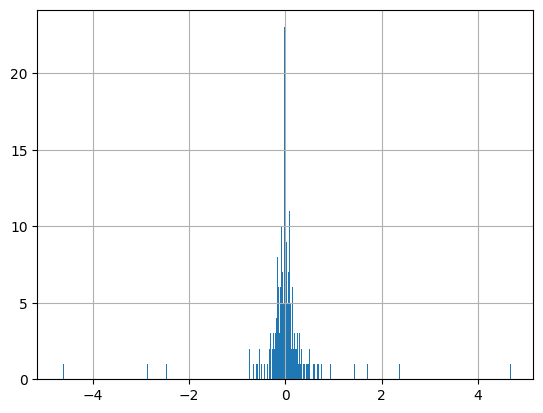

In [8]:
datapairs["normalized_time_delta"].hist(bins=1000)